# Demo 1 — Physics-Informed Neural Network for a damped harmonic oscillator

**Goal of this notebook:** see, end to end, what makes a PINN different from a plain neural network. We'll do three things in sequence:

1. **Plain NN, sparse data.** Train an MLP only on a handful of noisy measurements. It will fit the measurements but do nonsense between them.
2. **PINN, same data, plus physics.** Add a *physics-residual loss* that penalizes violations of the ODE on a grid of collocation points. The network now produces a smooth, physical trajectory even where there's no data.
3. **Inverse PINN.** Pretend we don't know the damping coefficient `c`. Make `c` a trainable parameter and recover it from the same sparse data.

The system is the simplest interesting one for this — a damped harmonic oscillator:

$$ m\,\ddot{x}(t) + c\,\dot{x}(t) + k\,x(t) = 0, \qquad x(0)=x_0,\ \dot{x}(0)=v_0. $$

Pick `m=1, k=1, c=0.5, x_0=1, v_0=0`. That's an underdamped oscillator with an analytical solution we can compare against.

**Things to play with** (see the last cell): the noise level, number of data points, network width/depth, physics-loss weight, training length, and whether the inverse problem can recover `c` when the data is very sparse or noisy.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = "cpu"  # tiny problem, CPU is faster than GPU launch overhead

# MIT branding for plots
MIT_RED = "#A31F34"
MIT_GRAY = "#8A8B8C"
plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Ground truth and a few noisy measurements

The underdamped analytical solution is

$$ x(t) = e^{-\zeta\omega_n t}\,\bigl(A\cos\omega_d t + B\sin\omega_d t\bigr), $$

with $\omega_n=\sqrt{k/m}$, $\zeta=c/(2\sqrt{km})$, $\omega_d=\omega_n\sqrt{1-\zeta^2}$. We use it only to make a "ground truth" curve and to sample a few noisy measurements. The PINN never sees this formula.

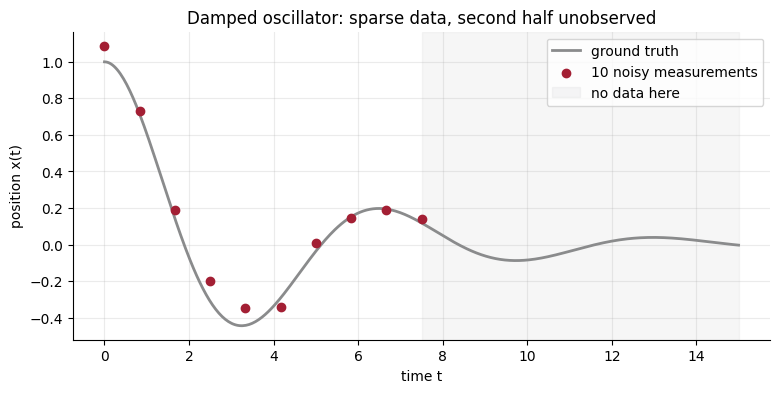

In [2]:
# Physical parameters
m, k, c_true = 1.0, 1.0, 0.5
x0, v0 = 1.0, 0.0
T = 15.0  # total time window

def analytical(t):
    omega_n = np.sqrt(k / m)
    zeta = c_true / (2 * np.sqrt(k * m))
    omega_d = omega_n * np.sqrt(1 - zeta**2)
    A = x0
    B = (v0 + zeta * omega_n * x0) / omega_d
    return np.exp(-zeta * omega_n * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))

# Dense grid for plotting the truth
t_dense = np.linspace(0, T, 400)
x_dense = analytical(t_dense)

# Sparse, noisy measurements — only in the first half of the window
N_DATA = 10
NOISE = 0.05
t_data = np.linspace(0, T / 2, N_DATA)
x_data = analytical(t_data) + NOISE * np.random.randn(N_DATA)

fig, ax = plt.subplots()
ax.plot(t_dense, x_dense, color=MIT_GRAY, lw=2, label="ground truth")
ax.scatter(t_data, x_data, color=MIT_RED, zorder=3, label=f"{N_DATA} noisy measurements")
ax.axvspan(T / 2, T, alpha=0.07, color=MIT_GRAY, label="no data here")
ax.set_xlabel("time t"); ax.set_ylabel("position x(t)")
ax.set_title("Damped oscillator: sparse data, second half unobserved")
ax.legend()
plt.show()

## Setting up the MLP for a physical problem

Before any code, a checklist of design choices — these are decisions you'll make every time you build a PINN for a real system. Most of them have one "obviously right" answer for ODE/PDE problems, but it's worth seeing each one called out so you know what you're committing to.

| Design choice | What we pick | Why |
|---|---|---|
| **Input** | scalar `t` (shape `[N, 1]`) | The independent variable of the ODE. For PDEs you'd add `x` and feed `[t, x]`. |
| **Output** | scalar `u` (shape `[N, 1]`) | The dependent variable we're solving for. |
| **Width / depth** | 48 units × 3 layers (~5k params) | Tiny by modern ML standards. Physics constrains the function class a lot — you almost never need a big network for an ODE. Rule of thumb: start small, grow only if loss plateaus above the noise floor. |
| **Activation** | `tanh` | Smooth, all derivatives exist, non-trivial $\ddot{f}$. ReLU is forbidden — its second derivative is zero almost everywhere, so the physics residual computes to zero for the wrong reason. `sin`, `GELU`, `Swish` all work; tanh is the default. |
| **Input scaling** | $t \to 2t/T - 1 \in [-1, 1]$ | <strong>The most important and most-forgotten step.</strong> Tanh saturates outside $[-3, 3]$. If you feed raw $t \in [0, 15]$, gradients vanish at the far end of the window, the physics residual is computed by a network that can't respond to its input, and PINN convergence stalls. Always normalize. |
| **Init** | PyTorch default (Kaiming-uniform) | Generally fine. Some PINN papers use Xavier-normal; the difference is usually within the seed-to-seed variance. |
| **Optimizer** | Adam, `lr=2e-3` | Robust default. Raissi's original PINNs polish with L-BFGS at the end; we skip that for clarity. |
| **Loss weights** | $\lambda_{\rm phys}=5$, $\lambda_{\rm ic}=20$, $\lambda_{\rm data}=1$ | IC weight needs to dominate or the network finds a low-physics-residual but wrong trajectory (often $u \equiv 0$). Physics weight is bumped above the data weight because the data-free half of the window has only physics to constrain it. |
| **Collocation points** | 200, uniformly across $[0, T]$ | Free — no measurements needed, just locations where the ODE should hold. More is fine; we use 200 because the residual is smooth and 200 is plenty. |

## Attempt 1 — plain MLP, fit the data only

To set a baseline, we first train without any physics — just minimize the mean-squared error against the 10 noisy points. Same MLP class, no physics-residual term. Watch what happens outside the data region.

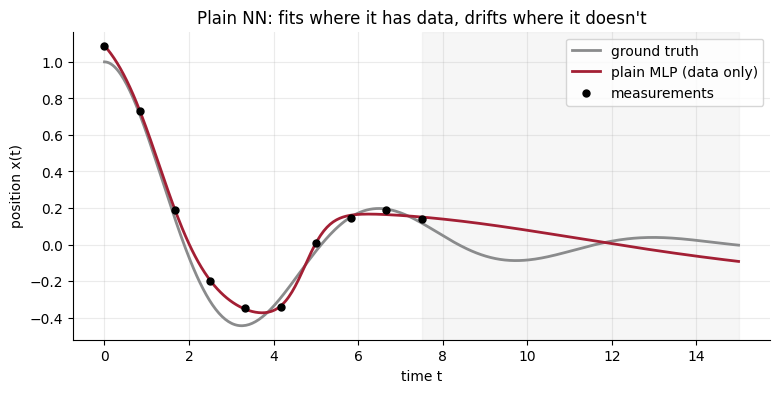

In [3]:
class MLP(nn.Module):
    '''Feedforward network with input normalization baked in.

    Two non-obvious things going on:
      1. The input `t` (raw seconds) is mapped to [-1, 1] in `forward` before
         touching any Linear layer. Without this, tanh saturates on large t
         and physics gradients vanish.
      2. Activation is tanh, NOT ReLU, because PINNs differentiate the network
         output up to second order. ReLU's second derivative is zero almost
         everywhere, which would make any physics residual artificially zero.
    '''
    def __init__(self, width: int = 48, depth: int = 3, t_max: float = T):
        super().__init__()
        self.t_max = t_max  # used to normalize input to [-1, 1]
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        # Normalize t from [0, t_max] to [-1, 1] so tanh stays in its
        # high-gradient regime everywhere in the window.
        t_norm = 2.0 * t / self.t_max - 1.0
        return self.net(t_norm)


def train_data_only(model, t_data, x_data, n_steps=4000, lr=2e-3):
    t = torch.tensor(t_data, dtype=torch.float32, device=device).view(-1, 1)
    x = torch.tensor(x_data, dtype=torch.float32, device=device).view(-1, 1)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for step in range(n_steps):
        opt.zero_grad()
        loss = ((model(t) - x) ** 2).mean()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses


model_data = MLP().to(device)
losses_data = train_data_only(model_data, t_data, x_data)

with torch.no_grad():
    t_eval = torch.tensor(t_dense, dtype=torch.float32, device=device).view(-1, 1)
    x_pred = model_data(t_eval).cpu().numpy().ravel()

fig, ax = plt.subplots()
ax.plot(t_dense, x_dense, color=MIT_GRAY, lw=2, label="ground truth")
ax.plot(t_dense, x_pred, color=MIT_RED, lw=2, label="plain MLP (data only)")
ax.scatter(t_data, x_data, color="black", zorder=3, s=25, label="measurements")
ax.axvspan(T / 2, T, alpha=0.07, color=MIT_GRAY)
ax.set_xlabel("time t"); ax.set_ylabel("position x(t)")
ax.set_title("Plain NN: fits where it has data, drifts where it doesn't")
ax.legend()
plt.show()

**What you should see:** the plain MLP nails the 10 measurement points (or overshoots them when noise is high) but in the right half of the time window — where there's no data — it has no reason to follow the physics, so it drifts off into whatever happens to minimize the loss. This is the standard failure mode of pure data-driven ML when data is sparse.

## Attempt 2 — add a physics-residual loss (a PINN)

The idea behind a PINN is one line: take the network's output $u_\theta(t)$, differentiate it with autograd to get $\dot{u}_\theta$ and $\ddot{u}_\theta$, and penalize the ODE residual

$$ r(t) = m\,\ddot{u}_\theta(t) + c\,\dot{u}_\theta(t) + k\,u_\theta(t) $$

at a grid of *collocation points* (cheap — no measurements needed, just points in time we want the physics to hold). We also pin the initial conditions and keep the small data-loss term.

Total loss:

$$ \mathcal{L} = \lambda_{\rm phys}\,\overline{r(t_i)^2} \;+\; \lambda_{\rm ic}\,\bigl[(u_\theta(0)-x_0)^2 + (\dot u_\theta(0)-v_0)^2\bigr] \;+\; \lambda_{\rm data}\,\overline{(u_\theta(t_j) - x_j)^2}. $$

The relative weights $\lambda$ are knobs — try changing them in the last section.

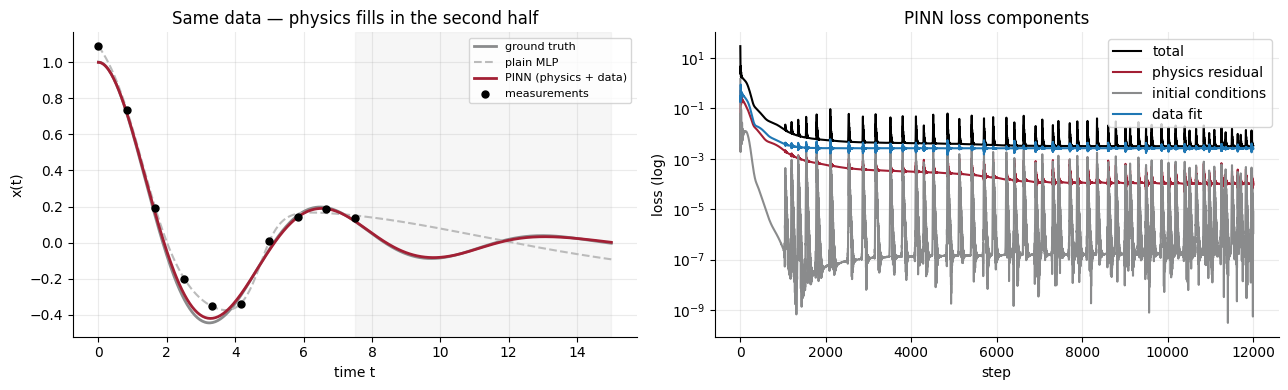

In [4]:
def derivative(y, t):
    '''First derivative dy/dt via autograd.

    `create_graph=True` lets us differentiate again (we need the second derivative).
    `grad_outputs=ones` is the standard recipe for elementwise vector-Jacobian products
    when y has the same shape as t.
    '''
    return torch.autograd.grad(
        y, t,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
    )[0]


def train_pinn(model, t_data, x_data, c_value=c_true,
               n_steps=12000, lr=2e-3,
               w_phys=5.0, w_ic=20.0, w_data=1.0,
               n_collocation=200):
    t_d = torch.tensor(t_data, dtype=torch.float32, device=device).view(-1, 1)
    x_d = torch.tensor(x_data, dtype=torch.float32, device=device).view(-1, 1)
    # Collocation points span the FULL time window — including the data-free region
    t_c = torch.linspace(0, T, n_collocation, device=device).view(-1, 1).requires_grad_(True)
    t0 = torch.zeros(1, 1, device=device, requires_grad=True)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = {"total": [], "phys": [], "ic": [], "data": []}

    for step in range(n_steps):
        opt.zero_grad()

        # Physics residual on collocation points
        u_c = model(t_c)
        u_t = derivative(u_c, t_c)
        u_tt = derivative(u_t, t_c)
        residual = m * u_tt + c_value * u_t + k * u_c
        loss_phys = (residual ** 2).mean()

        # Initial conditions
        u0 = model(t0)
        u_t0 = derivative(u0, t0)
        loss_ic = (u0 - x0).pow(2).mean() + (u_t0 - v0).pow(2).mean()

        # Data fit
        loss_data = ((model(t_d) - x_d) ** 2).mean()

        loss = w_phys * loss_phys + w_ic * loss_ic + w_data * loss_data
        loss.backward()
        opt.step()

        losses["total"].append(loss.item())
        losses["phys"].append(loss_phys.item())
        losses["ic"].append(loss_ic.item())
        losses["data"].append(loss_data.item())

    return losses


model_pinn = MLP().to(device)
losses_pinn = train_pinn(model_pinn, t_data, x_data)

with torch.no_grad():
    x_pred_pinn = model_pinn(t_eval).cpu().numpy().ravel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(t_dense, x_dense, color=MIT_GRAY, lw=2, label="ground truth")
ax1.plot(t_dense, x_pred, color="#bbbbbb", lw=1.5, ls="--", label="plain MLP")
ax1.plot(t_dense, x_pred_pinn, color=MIT_RED, lw=2, label="PINN (physics + data)")
ax1.scatter(t_data, x_data, color="black", zorder=3, s=25, label="measurements")
ax1.axvspan(T / 2, T, alpha=0.07, color=MIT_GRAY)
ax1.set_xlabel("time t"); ax1.set_ylabel("x(t)")
ax1.set_title("Same data — physics fills in the second half")
ax1.legend(loc="upper right", fontsize=8)

ax2.semilogy(losses_pinn["total"], color="black", label="total")
ax2.semilogy(losses_pinn["phys"], color=MIT_RED, label="physics residual")
ax2.semilogy(losses_pinn["ic"], color=MIT_GRAY, label="initial conditions")
ax2.semilogy(losses_pinn["data"], color="tab:blue", label="data fit")
ax2.set_xlabel("step"); ax2.set_ylabel("loss (log)")
ax2.set_title("PINN loss components")
ax2.legend()
plt.tight_layout(); plt.show()

**What you should see:** the PINN curve follows the true oscillation through the entire window, including where there's no data. The physics-residual loss doesn't need measurements — it just needs *time points* where the ODE should hold. That's the whole trick.

A few intuitions worth pausing on:

- **Collocation points are free.** They're not data; they're just locations where we ask the network to obey the equation. We can put 200, 2000, 20000 — only compute cost grows.
- **Autodiff does the differentiation symbolically-ish.** We never write a finite-difference formula. `torch.autograd.grad` walks the computation graph and returns exact derivatives at machine precision.
- **The activation matters.** Tanh is smooth; its derivatives exist and are non-trivial. ReLU's second derivative is zero almost everywhere — a ReLU PINN would have a zero physics residual for the wrong reason.

## Attempt 3 — Inverse problem: discover the damping coefficient `c`

Now we *don't* know `c`. We have the same 10 noisy measurements and the same ODE form. We let `c` be a trainable parameter alongside the network weights and minimize the same loss.

This is the killer use case in industrial settings: you have physics that's *structurally* right but with one or two unknown coefficients that drift across batches, materials, or operating points. Fit them from telemetry.

true c       = 0.5000
recovered c  = 0.5813
absolute err = 0.0813


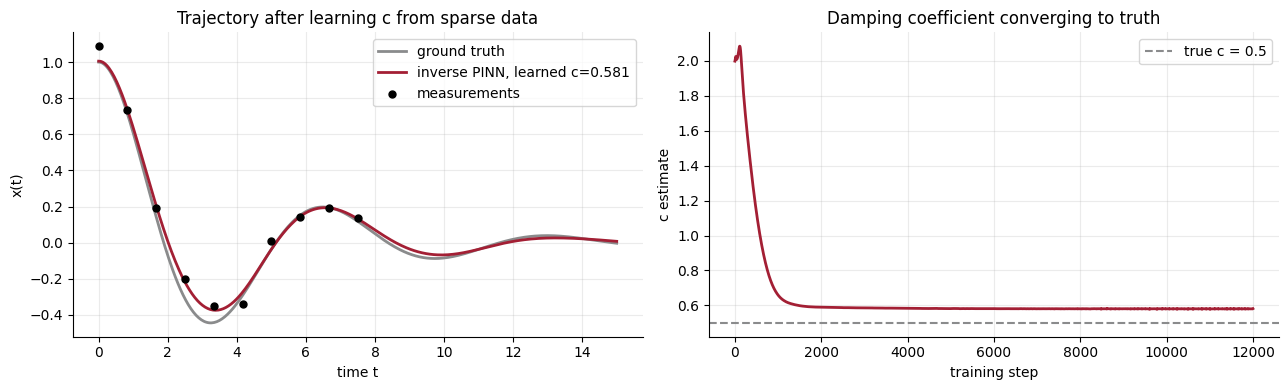

In [5]:
class InversePINN(nn.Module):
    '''Same MLP (with input normalization) but with a learnable damping `c`.

    The only structural difference from the forward PINN is `self.c` — a
    single nn.Parameter that the optimizer will update alongside the network
    weights. This is the "make it learnable" idiom in PyTorch.
    '''
    def __init__(self, c_init: float = 2.0, width: int = 48, depth: int = 3, t_max: float = T):
        super().__init__()
        self.mlp = MLP(width=width, depth=depth, t_max=t_max)
        # Start far from the true value (0.5) so we can see it move
        self.c = nn.Parameter(torch.tensor(c_init, dtype=torch.float32))

    def forward(self, t):
        return self.mlp(t)


def train_inverse(model, t_data, x_data,
                  n_steps=12000, lr=2e-3,
                  w_phys=5.0, w_ic=20.0, w_data=10.0,
                  n_collocation=200):
    t_d = torch.tensor(t_data, dtype=torch.float32, device=device).view(-1, 1)
    x_d = torch.tensor(x_data, dtype=torch.float32, device=device).view(-1, 1)
    t_c = torch.linspace(0, T, n_collocation, device=device).view(-1, 1).requires_grad_(True)
    t0 = torch.zeros(1, 1, device=device, requires_grad=True)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    c_history = []
    loss_history = []

    for step in range(n_steps):
        opt.zero_grad()

        u_c = model(t_c)
        u_t = derivative(u_c, t_c)
        u_tt = derivative(u_t, t_c)
        residual = m * u_tt + model.c * u_t + k * u_c
        loss_phys = (residual ** 2).mean()

        u0 = model(t0)
        u_t0 = derivative(u0, t0)
        loss_ic = (u0 - x0).pow(2).mean() + (u_t0 - v0).pow(2).mean()

        loss_data = ((model(t_d) - x_d) ** 2).mean()

        loss = w_phys * loss_phys + w_ic * loss_ic + w_data * loss_data
        loss.backward()
        opt.step()

        c_history.append(model.c.item())
        loss_history.append(loss.item())

    return c_history, loss_history


model_inv = InversePINN(c_init=2.0).to(device)
c_history, loss_history = train_inverse(model_inv, t_data, x_data)

print(f"true c       = {c_true:.4f}")
print(f"recovered c  = {model_inv.c.item():.4f}")
print(f"absolute err = {abs(model_inv.c.item() - c_true):.4f}")

with torch.no_grad():
    x_pred_inv = model_inv(t_eval).cpu().numpy().ravel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(t_dense, x_dense, color=MIT_GRAY, lw=2, label="ground truth")
ax1.plot(t_dense, x_pred_inv, color=MIT_RED, lw=2, label=f"inverse PINN, learned c={model_inv.c.item():.3f}")
ax1.scatter(t_data, x_data, color="black", zorder=3, s=25, label="measurements")
ax1.set_xlabel("time t"); ax1.set_ylabel("x(t)")
ax1.set_title("Trajectory after learning c from sparse data")
ax1.legend()

ax2.plot(c_history, color=MIT_RED, lw=2)
ax2.axhline(c_true, color=MIT_GRAY, ls="--", label=f"true c = {c_true}")
ax2.set_xlabel("training step"); ax2.set_ylabel("c estimate")
ax2.set_title("Damping coefficient converging to truth")
ax2.legend()
plt.tight_layout(); plt.show()

## Things to play with

Each of these breaks something interesting:

- **`NOISE`** (top): crank to 0.2. The inverse fit gets biased; with enough noise, you can't recover `c` accurately from 10 points.
- **`N_DATA`** (top): drop to 3. PINN still works because physics constrains the shape; plain NN can't even fit.
- **`w_phys`** (PINN training): set to 0. You've reduced the PINN to a plain NN. Set to 100. The fit gets *too* stiff and ignores noisy data.
- **`w_ic`** (PINN training): set to 0. The PINN drifts because nothing pins down the starting point.
- **Move the data region** to `[T/2, T]` instead of `[0, T/2]`. The PINN extrapolates *backwards*. Plain NN extrapolates nowhere useful.
- **Inverse `c_init`**: start at 10. The optimizer can get stuck — non-convex landscape. Try a few initializations.
- **Activation:** in `MLP`, swap `nn.Tanh()` for `nn.ReLU()`. The physics residual goes to zero for the wrong reason and the network fits arbitrary nonsense.

The sidebar coming up (Section 5 in the slides) is what happens when you push this idea past one scalar `c` to a whole *function* `h_e(T_gas, v_gas, T_drum)` that lives inside a multi-state thermal ODE. That's [my paper](../main.pdf).